In [14]:
import pandas as pd
import numpy as np
from ta.trend import sma_indicator, ema_indicator, macd
from ta.momentum import rsi, stoch, roc
from ta.volatility import BollingerBands, average_true_range
from ta.volume import on_balance_volume, money_flow_index
from statsmodels.tsa.stattools import adfuller
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load Data
path = "C:/Users/yhsol/Documents/Python Scripts/Stock Market/META_alpha_1min_2024-05_to_2025-05.csv"
df = pd.read_csv(path)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

In [15]:
import pandas as pd
import numpy as np
from ta.trend import SMAIndicator, EMAIndicator, MACD, ADXIndicator, CCIIndicator, DPOIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator, TSIIndicator, WilliamsRIndicator, KAMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange, DonchianChannel
from ta.volume import OnBalanceVolumeIndicator
# Money Flow Index (MFI)
def money_flow_index(high, low, close, volume, window=14):
    typical_price = (high + low + close) / 3
    money_flow = typical_price * volume
    pos_flow = money_flow.where(typical_price > typical_price.shift(1), 0)
    neg_flow = money_flow.where(typical_price < typical_price.shift(1), 0)
    pos_mf_sum = pos_flow.rolling(window=window).sum()
    neg_mf_sum = neg_flow.rolling(window=window).sum()
    mfi = 100 - (100 / (1 + (pos_mf_sum / neg_mf_sum)))
    return mfi

# Chaikin Money Flow (CMF)
def chaikin_money_flow(high, low, close, volume, window=20):
    mf_multiplier = ((close - low) - (high - close)) / (high - low).replace(0, np.nan)
    mf_volume = mf_multiplier * volume
    cmf = mf_volume.rolling(window=window).sum() / volume.rolling(window=window).sum()
    return cmf


df_indicators = pd.DataFrame(index=df.index)

# Trend
df_indicators['sma_20'] = SMAIndicator(df['Close'], window=20).sma_indicator()
df_indicators['ema_12'] = EMAIndicator(df['Close'], window=12).ema_indicator()
df_indicators['macd'] = MACD(df['Close']).macd()
df_indicators['adx'] = ADXIndicator(df['High'], df['Low'], df['Close']).adx()
df_indicators['cci'] = CCIIndicator(df['High'], df['Low'], df['Close']).cci()
df_indicators['dpo'] = DPOIndicator(df['Close']).dpo()

# Momentum
df_indicators['rsi_14'] = RSIIndicator(df['Close'], window=14).rsi()
df_indicators['stoch_k'] = StochasticOscillator(df['High'], df['Low'], df['Close']).stoch()
df_indicators['roc'] = ROCIndicator(df['Close'], window=12).roc()
df_indicators['tsi'] = TSIIndicator(df['Close']).tsi()
df_indicators['williams_r'] = WilliamsRIndicator(df['High'], df['Low'], df['Close']).williams_r()
df_indicators['kama'] = KAMAIndicator(df['Close']).kama()

# Volatility
bb = BollingerBands(df['Close'])
df_indicators['bb_mavg'] = bb.bollinger_mavg()
df_indicators['bb_high'] = bb.bollinger_hband()
df_indicators['bb_low'] = bb.bollinger_lband()
df_indicators['atr'] = AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
donchian = DonchianChannel(high=df['High'], low=df['Low'], close=df['Close'])
df_indicators['donchian_high'] = donchian.donchian_channel_hband()
df_indicators['donchian_low'] = donchian.donchian_channel_lband()

# Volume
df_indicators['obv'] = OnBalanceVolumeIndicator(df['Close'], df['Volume']).on_balance_volume()
df_indicators['mfi'] = money_flow_index(df['High'], df['Low'], df['Close'], df['Volume'])
df_indicators['cmf'] = chaikin_money_flow(df['High'], df['Low'], df['Close'], df['Volume'])



In [16]:

# Add Close return (log return)
df_indicators['Close_return'] = np.log(df['Close']).diff()

In [17]:
df_indicators.dropna(inplace=True)
from joblib import Parallel, delayed
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def make_stationary(series, maxlag=10):
    series_clean = series.dropna()
    # Skip empty series
    if len(series_clean) < maxlag + 1:
        return series  # or you could return pd.Series(np.nan, index=series.index)
    
    p_value = adfuller(series_clean, maxlag=maxlag)[1]
    return series.diff() if p_value > 0.05 else series

def process_in_batches(df, batch_size=5, n_jobs=2, maxlag=10):
    cols = df.columns
    stationary_results = []

    for i in range(0, len(cols), batch_size):
        batch_cols = cols[i:i+batch_size]
        results = Parallel(n_jobs=n_jobs)(
            delayed(make_stationary)(df[col], maxlag=maxlag) for col in batch_cols
        )
        batch_df = pd.concat(results, axis=1)
        batch_df.columns = batch_cols
        stationary_results.append(batch_df)

    stationary_df = pd.concat(stationary_results, axis=1)
    stationary_df.dropna(inplace=True)
    return stationary_df

# Example usage:
stationary_df = process_in_batches(df_indicators, batch_size=5, n_jobs=2, maxlag=10)


In [18]:
 #5️⃣ Shift to avoid leakage
df_shifted = stationary_df.shift(1).dropna()

# 6️⃣ Standardize
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_shifted),
                         columns=df_shifted.columns,
                         index=df_shifted.index)

# 7️⃣ Prepare for Tigramite
columns_to_keep = df_scaled.columns.tolist()
dataframe = pp.DataFrame(df_scaled.values, var_names=columns_to_keep)


In [19]:
from tigramite.independence_tests.parcorr import ParCorr
# 8️⃣ Run PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr)

results = pcmci.run_pcmci(tau_max=5, pc_alpha=0.05)

In [20]:
# 9️⃣ Evaluate causal links
target_index = columns_to_keep.index("Close_return")
q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], fdr_method='fdr_bh')
val_matrix = results['val_matrix']

causal_links = []
for i, col in enumerate(columns_to_keep):
    for lag in range(1, 6):
        p_val = q_matrix[i, target_index, lag-1]
        if p_val <= 0.05:
            strength = val_matrix[i, target_index, lag-1]
            causal_links.append((col, f"Lag {lag}", p_val, strength))



📊 Top Causal Indicators (affecting 'Close_return'):
macd at Lag 1 | p-value: 0.0000, strength: 0.9629
roc at Lag 1 | p-value: 0.0000, strength: 0.9580
ema_12 at Lag 1 | p-value: 0.0000, strength: 0.9309
kama at Lag 1 | p-value: 0.0000, strength: 0.6988
sma_20 at Lag 1 | p-value: 0.0000, strength: 0.5828
bb_mavg at Lag 1 | p-value: 0.0000, strength: 0.5828
tsi at Lag 1 | p-value: 0.0000, strength: 0.4210
bb_low at Lag 1 | p-value: 0.0000, strength: 0.4010
rsi_14 at Lag 1 | p-value: 0.0000, strength: 0.3275
cci at Lag 1 | p-value: 0.0000, strength: 0.2306
bb_high at Lag 1 | p-value: 0.0000, strength: -0.2301
donchian_low at Lag 1 | p-value: 0.0000, strength: 0.2127
stoch_k at Lag 1 | p-value: 0.0000, strength: 0.1821
williams_r at Lag 1 | p-value: 0.0000, strength: 0.1821
Close_return at Lag 2 | p-value: 0.0000, strength: -0.1489
atr at Lag 1 | p-value: 0.0000, strength: -0.1397
Close_return at Lag 4 | p-value: 0.0000, strength: -0.1184
roc at Lag 2 | p-value: 0.0000, strength: -0.1094


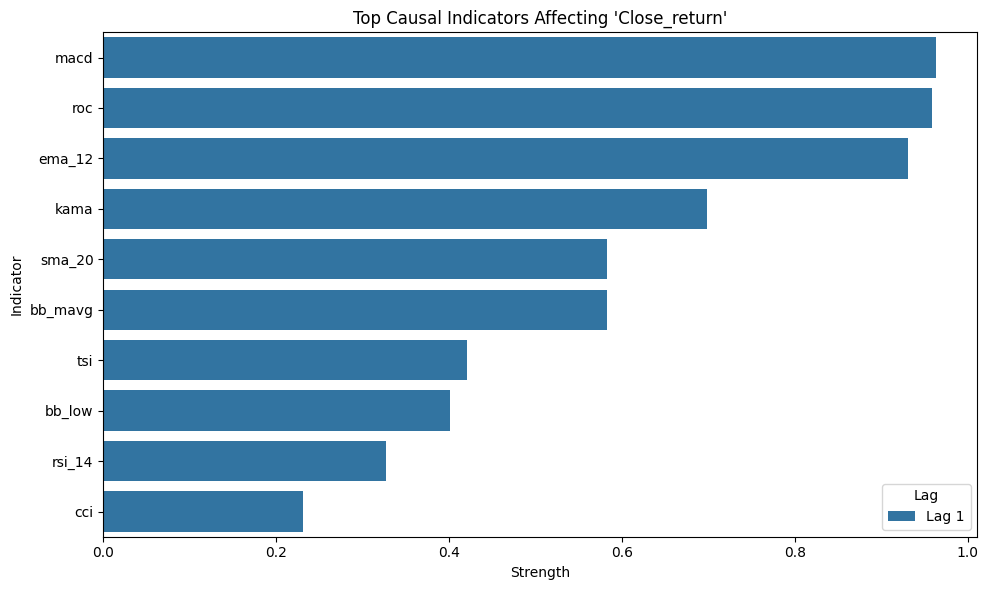

In [21]:
# 10️⃣ Show top results
causal_links_sorted = sorted(causal_links, key=lambda x: abs(x[3]), reverse=True)
print("\n📊 Top Causal Indicators (affecting 'Close_return'):")
for link in causal_links_sorted:
    print(f"{link[0]} at {link[1]} | p-value: {link[2]:.4f}, strength: {link[3]:.4f}")

# 11️⃣ Optional: Plot
plot_top_n = 10
top_df = pd.DataFrame(causal_links_sorted[:plot_top_n], columns=["Indicator", "Lag", "p-value", "Strength"])
plt.figure(figsize=(10, 6))
sns.barplot(data=top_df, y="Indicator", x="Strength", hue="Lag")
plt.title("Top Causal Indicators Affecting 'Close_return'")
plt.tight_layout()
plt.show()


In [22]:
import os

# Prepare DataFrame
top_df = pd.DataFrame(causal_links_sorted[:plot_top_n], columns=["Indicator", "Lag", "p-value", "Strength"])

# Define the path to the Downloads folder
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "top_causal_indicators.csv")

# Save to CSV
top_df.to_csv(downloads_path, index=False)

print(f"✅ CSV saved to: {downloads_path}")

✅ CSV saved to: C:\Users\yhsol\Downloads\top_causal_indicators.csv


In [23]:
corr_matrix = df_indicators.corr().abs()

# 2. Zero out the diagonal (self‐correlation)
np.fill_diagonal(corr_matrix.values, 0)

# 3. Find pairs where |corr| > 0.90
low_corr_pairs = (
    corr_matrix
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
    .query("abs_corr <0.90")
)

# Display which pairs exceed threshold
print("Highly correlated pairs (|corr| > 0.90):")
print(low_corr_pairs.to_string(index=False))  # lists var1, var2, abs_corr


Highly correlated pairs (|corr| > 0.90):
         var1          var2  abs_corr
       sma_20        sma_20  0.000000
       sma_20          macd  0.001888
       sma_20           adx  0.031667
       sma_20           cci  0.009497
       sma_20           dpo  0.002371
       sma_20        rsi_14  0.005077
       sma_20       stoch_k  0.016204
       sma_20           roc  0.005635
       sma_20           tsi  0.000153
       sma_20    williams_r  0.016204
       sma_20           atr  0.058519
       sma_20           obv  0.745512
       sma_20           mfi  0.007381
       sma_20           cmf  0.040774
       sma_20  Close_return  0.000938
       ema_12        ema_12  0.000000
       ema_12          macd  0.009306
       ema_12           adx  0.031514
       ema_12           cci  0.005146
       ema_12           dpo  0.000390
       ema_12        rsi_14  0.000358
       ema_12       stoch_k  0.020138
       ema_12           roc  0.000184
       ema_12           tsi  0.005543
       em

In [24]:
import os

# Get the path to the Downloads folder
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "low_correlation_pairs.csv")

# Save to CSV
low_corr_pairs.to_csv(downloads_path, index=False)

print(f"✅ CSV saved to: {downloads_path}")


✅ CSV saved to: C:\Users\yhsol\Downloads\low_correlation_pairs.csv
